In [1]:
# load the model parts: 3 onnx graphs + tokenizer + service config
import json
from pathlib import Path

import numpy as np
import onnxruntime as ort
from PIL import Image
from tokenizers import Tokenizer

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # recognition/
D = ROOT / "onnx_out"
PROVIDERS = ["CPUExecutionProvider"]        # or ["CUDAExecutionProvider", "CPUExecutionProvider"]

enc_sess  = ort.InferenceSession(str(D / "encoder_model.onnx"), providers=PROVIDERS)
dec_sess  = ort.InferenceSession(str(D / "decoder_model.onnx"), providers=PROVIDERS)
past_sess = ort.InferenceSession(str(D / "decoder_with_past_model.onnx"), providers=PROVIDERS)
tok = Tokenizer.from_file(str(D / "tokenizer.json"))
cfg = json.loads((D / "service_config.json").read_text(encoding="utf-8"))
cfg

{'image_size': 384,
 'image_mean': [0.5, 0.5, 0.5],
 'image_std': [0.5, 0.5, 0.5],
 'resample': 3,
 'decoder_start_token_id': 0,
 'eos_token_id': 2,
 'pad_token_id': 1,
 'vocab_size': 65000,
 'max_length': 128}

Декодер — трансформер. На каждом шаге генерации каждый слой считает attention, для которого нужны K (key) и V (value) тензоры всех предыдущих токенов. Без кэша на шаге 50 пришлось бы заново прогонять все 50 токенов через все слои — O(n²) работы. С кэшем: K/V, посчитанные один раз, сохраняются, и на каждом шаге через декодер прогоняется только один новый токен, а его attention смотрит в сохранённые K/V.

У энкодер-декодера кэш двух сортов:

- present.{i}.decoder.key/value — self-attention: K/V сгенерированных токенов. Растёт на 1 с каждым шагом.
- present.{i}.encoder.key/value — cross-attention: K/V, посчитанные из выхода энкодера (картинки). Картинка не меняется → считаются один раз и дальше константа.

({i} — номер слоя, у нас их 6, значит в кэше 6×4=24 тензора.)

In [3]:
inputs = past_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = past_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: input_ids, shape: ['batch_size', 'decoder_sequence_length'], type: tensor(int64)
Input name: past_key_values.0.decoder.key, shape: ['batch_size', 8, 'past_decoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.0.decoder.value, shape: ['batch_size', 8, 'past_decoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.0.encoder.key, shape: ['batch_size', 8, 'encoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.0.encoder.value, shape: ['batch_size', 8, 'encoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.1.decoder.key, shape: ['batch_size', 8, 'past_decoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.1.decoder.value, shape: ['batch_size', 8, 'past_decoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.1.encoder.key, shape: ['batch_size', 8, 'encoder_sequence_length', 32], type: tensor(float)
Input name: past_key_values.1.encoder.val

In [66]:
# !python -m pip install --force-reinstall -U ap_res_models_inference --index-url https://nexus.ap-team.ru/repository/pypi/simple

from ap_res_models_inference import get_model
import numpy as np

model = get_model(
    engine_name= 'onnx',
    path_to_weights=str(D / "encoder_model.onnx"),
    use_gpu=0
)

dummy_input = torch.randn(1, 3, 384, 384, device='cpu')

outputs = model(pixel_values=np.array(dummy_input))
outputs.shape

/tmp/ipykernel_3632/1833013629.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  outputs = model(pixel_values=np.array(dummy_input)) # image_input namespace from export


(1, 578, 384)

### Example

In [2]:
RESAMPLE = {0: Image.NEAREST, 2: Image.BILINEAR, 3: Image.BICUBIC}.get(cfg.get("resample", 2), Image.BILINEAR)
MEAN = np.array(cfg["image_mean"], np.float32)
STD  = np.array(cfg["image_std"], np.float32)
START, EOS = cfg["decoder_start_token_id"], cfg["eos_token_id"]

dec_out  = [o.name for o in dec_sess.get_outputs()]
past_in  = [i.name for i in past_sess.get_inputs()]
past_out = [o.name for o in past_sess.get_outputs()]


def preprocess(img):
    s = cfg["image_size"]
    a = np.asarray(img.convert("RGB").resize((s, s), RESAMPLE), np.float32) / 255.0
    return ((a - MEAN) / STD).transpose(2, 0, 1)[None]


def first_step(ids, enc):
    outs = dec_sess.run(None, {"input_ids": ids, "encoder_hidden_states": enc})
    cache = {n: v for n, v in zip(dec_out, outs) if n.startswith("present")}
    return outs[dec_out.index("logits")], cache


def next_step(last, enc, cache):
    feeds = {}
    for n in past_in:                                  # feed by the graph's own input names
        if n == "input_ids":
            feeds[n] = last
        elif n == "encoder_hidden_states":
            feeds[n] = enc
        elif n.startswith("past_key_values"):
            feeds[n] = cache[n.replace("past_key_values", "present", 1)]
    outs = past_sess.run(None, feeds)
    for n, v in zip(past_out, outs):
        if n.startswith("present"):
            cache[n] = v                               # graphs return the full past+new KV
    return outs[past_out.index("logits")], cache


def recognize(img, max_length=None):
    enc = enc_sess.run(None, {"pixel_values": preprocess(img)})[0]
    logits, cache = first_step(np.array([[START]], np.int64), enc)
    seq = []
    for _ in range((max_length or cfg["max_length"]) - 1):
        t = int(logits[0, -1].argmax())
        if t == EOS:
            break
        seq.append(t)
        logits, cache = next_step(np.array([[t]], np.int64), enc, cache)
    return tok.decode(seq, skip_special_tokens=True).strip()

print("ready")  # beam search: see runtime_onnx.OnnxTrOCR.recognize_beam

ready


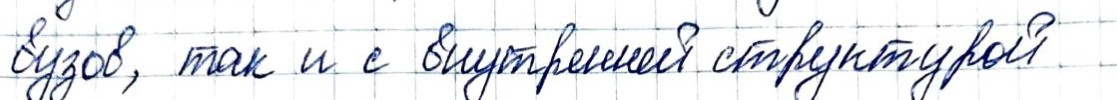

дузов, так и с внутренней структурой


In [59]:
path = "/mnt/DATA2/dorin/handwriting-recognition/data/lines/line9.jpg"

img = Image.open(path)
display(img)
print(recognize(img))

In [40]:
from transformers import AutoImageProcessor
from PIL import Image

CKPT = "../outputs/trocr_small_bi_finetune_with_hwr200_cleaned/best"
ip = AutoImageProcessor.from_pretrained(CKPT)

path = "/mnt/DATA2/dorin/handwriting-recognition/data/lines/line2.jpg"
img = Image.open(path)
px_ref = ip(images=img, return_tensors="np").pixel_values   # что видит torch-модель
px_our = preprocess(img)                                    # что видит ONNX

print("shapes:", px_ref.shape, px_our.shape)
print("max |diff|:", np.abs(px_ref - px_our).max())

print({k: getattr(ip, k, None) for k in
       ("size", "resample", "image_mean", "image_std", "do_rescale", "rescale_factor")})

shapes: (1, 3, 384, 384) (1, 3, 384, 384)
max |diff|: 0.0
{'size': {'height': 384, 'width': 384}, 'resample': 3, 'image_mean': [0.5, 0.5, 0.5], 'image_std': [0.5, 0.5, 0.5], 'do_rescale': True, 'rescale_factor': 0.00392156862745098}


In [37]:
from transformers import AutoImageProcessor, AutoTokenizer, TrOCRProcessor, VisionEncoderDecoderModel

CKPT = "../outputs/trocr_small_bi_finetune_with_hwr200_cleaned_v4/best"
DEVICE = "cpu"

model = VisionEncoderDecoderModel.from_pretrained(CKPT).to(DEVICE).eval()
processor = TrOCRProcessor(
    image_processor=AutoImageProcessor.from_pretrained(CKPT),
    tokenizer=AutoTokenizer.from_pretrained(CKPT),
)
print("loaded:", CKPT, "| device:", DEVICE)

Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.47.1"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

loaded: ../outputs/trocr_small_bi_finetune_with_hwr200_cleaned_v4/best | device: cpu


In [51]:
@torch.no_grad()
def recognize(image, num_beams=1):
    if isinstance(image, (str, Path)):
        image = Image.open(image).convert('RGB')
    pv = processor(images=image, return_tensors='pt').pixel_values.to(DEVICE)
    ids = model.generate(pv, num_beams=num_beams, max_new_tokens=128)
    return processor.tokenizer.batch_decode(ids, skip_special_tokens=True)[0]

In [52]:
recognize(img)

'the letter are just right'

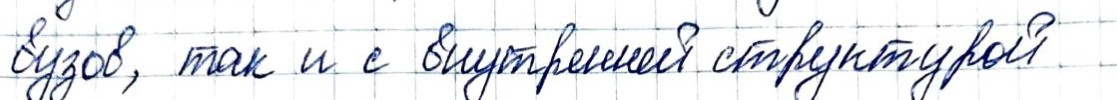

beam-4: дузов, так и с внутренней структурой
greedy: дузов, так и с внутренней структурой

greedy 51 ms/line | beam-4 171 ms/line
image1.png
  greedy: Со слов соседей нашего дома, стало
  beam  : Со слов соседей нашего дома, стало   ==
image2.png
  greedy: считает, что "нет ничего медленней
  beam  : считает, что "нет ничего медленней   ==
image3.png
  greedy: с тобой в минуты неудач. У
  beam  : с тобой в минуты неудач. У   ==
image4.png
  greedy: чем будет заниматься в жизни, но
  beam  : чем будет заниматься в жизни, но   ==


In [71]:
import sys, time
from pathlib import Path
from PIL import Image

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # recognition/
sys.path.insert(0, str(ROOT / "onnx"))
from model import load_model

m = load_model(ROOT / "onnx_out", num_beams=4)     # все параметры из service_config.json

path = "/mnt/DATA2/dorin/handwriting-recognition/data/lines/line9.jpg"
img = Image.open(path)
display(img)
print("beam-4:", m.recognize(img))
print("greedy:", m.recognize(img, num_beams=1))

paths = sorted(Path("/mnt/DATA2/dorin/handwriting-recognition/data/lines").glob("*.png"))[:8]   # <- своя папка с кропами
imgs = [Image.open(p) for p in paths]

t0 = time.perf_counter()
texts_g = m.recognize_batch(imgs, num_beams=1)                 # батчевый greedy
dt_g = (time.perf_counter() - t0) / len(imgs)

t0 = time.perf_counter()
texts_b = m.recognize_batch(imgs)                              # beam по строкам, энкодер батчем
dt_b = (time.perf_counter() - t0) / len(imgs)

print(f"\ngreedy {dt_g*1e3:.0f} ms/line | beam-4 {dt_b*1e3:.0f} ms/line")
for p, tg, tb in zip(paths, texts_g, texts_b):
    mark = "==" if tg == tb else "!="
    print(f"{p.name}\n  greedy: {tg}\n  beam  : {tb}   {mark}")